Environment: the `etunc` kernel (`envs/etunc.yml`, with the repo installed editable).

# Compare ILAMB observational products

In [30]:
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt

import etunc.units as units

In [31]:
ILAMB_DATA_ROOT = Path("/glade/campaign/univ/uwas0155/obs/ilamb/ILAMB-Data")
VARIABLES = ["evspsbl", "hfls", "rns", "pr"]
TIME_SLICE = slice("2000-01", "2019-12")
ET_VARNAMES = ["et", "hfls", "le"]

In [32]:
LATENT_HEAT_VAPORIZATION = 2.45e6  # J/kg
LIQ_WATER_DENSITY = 1e3            # kg/m3

In [60]:
products = {}

for v in VARIABLES:
    print(v)
    products[v] = {}

    for p in ILAMB_DATA_ROOT.joinpath(v).iterdir():
    
        if p.name not in ("FLUXNET2015", "WRMC.BSRN"):
            products[v][p.name] = []

            for f in p.iterdir():
                print(p.name)
                ds = xr.open_dataset(f, decode_timedelta=False)

                print(f"  {f}")
                print(f"  {ds.time[0].item().strftime(format="%Y-%m-%d")} to {ds.time[-1].item().strftime(format="%Y-%m-%d")}")
                print(f"  {list(ds.variables.keys())}")

                if v in ("evspsbl", "hfls"):
                    for et_v in ET_VARNAMES:
                        try:
                            products[v][p.name].append(units.latent_heat_to_wm2(ds[et_v]))
                            break
                        except KeyError:
                            continue
                else:
                    products[v][p.name].append(ds[v])

                print(f"  {v}: {products[v][p.name][0].units}")            

    print()

evspsbl
DOLCE
  /glade/campaign/univ/uwas0155/obs/ilamb/ILAMB-Data/evspsbl/DOLCE/DOLCE.nc
  2000-01-16 to 2009-12-16
  ['time_bounds', 'hfls', 'hfls_bnds', 'time', 'lat', 'lon']
  evspsbl: W/m2
GLEAMv3.3a
  /glade/campaign/univ/uwas0155/obs/ilamb/ILAMB-Data/evspsbl/GLEAMv3.3a/et.nc
  1980-01-16 to 2018-12-16
  ['time_bounds', 'lat_bounds', 'lon_bounds', 'et', 'time', 'lat', 'lon']
  evspsbl: W/m2
MOD16A2
  /glade/campaign/univ/uwas0155/obs/ilamb/ILAMB-Data/evspsbl/MOD16A2/et.nc
  2000-01-16 to 2014-12-16
  ['time_bounds', 'lat_bounds', 'lon_bounds', 'et', 'time', 'lat', 'lon']
  evspsbl: W/m2
CARDAMOM
  /glade/campaign/univ/uwas0155/obs/ilamb/ILAMB-Data/evspsbl/CARDAMOM/et.nc
  2001-01-16 to 2021-12-16
  ['et', 'et_bnds', 'lat', 'lon', 'time', 'time_bnds', 'lat_bnds', 'lon_bnds']
  evspsbl: W/m2
MODIS
  /glade/campaign/univ/uwas0155/obs/ilamb/ILAMB-Data/evspsbl/MODIS/et_0.5x0.5.nc
  2000-01-16 to 2013-12-16
  ['time_bounds', 'et', 'time', 'lat', 'lon']
  evspsbl: W/m2

hfls
WECANN
  /g

hfls WECANN
hfls FLUXCOM


hfls CLASS
evspsbl DOLCE
evspsbl GLEAMv3.3a
evspsbl MOD16A2
evspsbl CARDAMOM
evspsbl MODIS


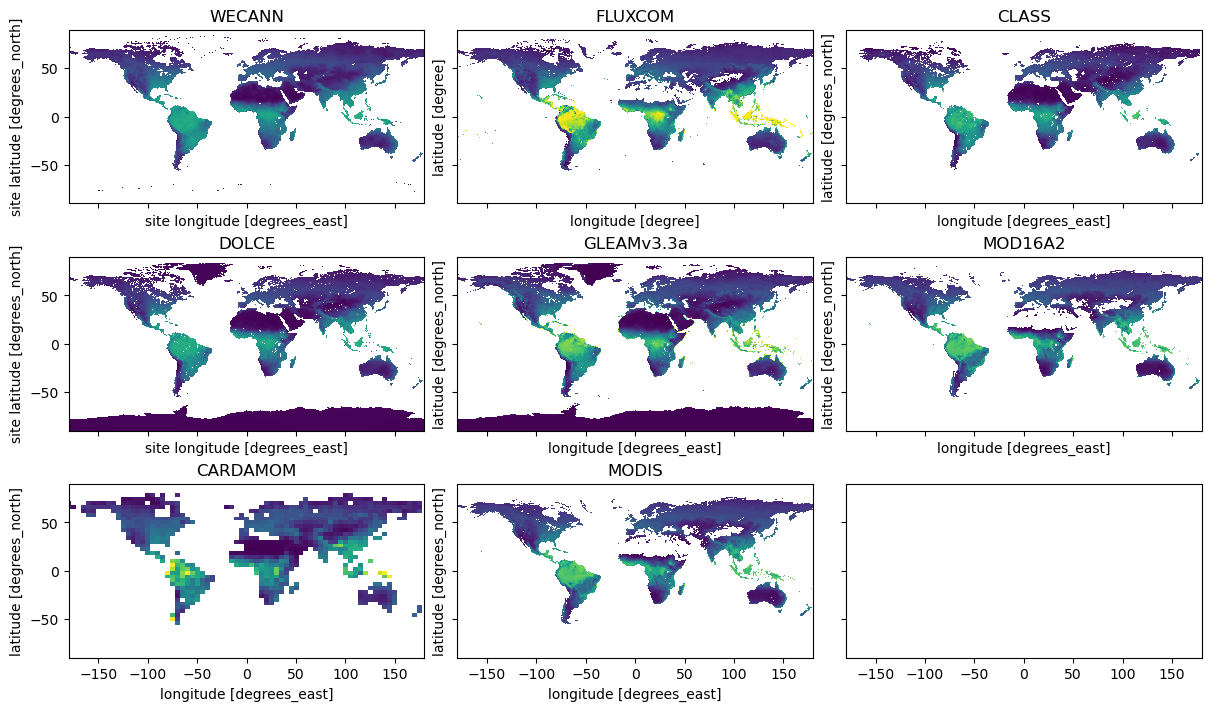

In [70]:
fig, axes = plt.subplots(3, 3, figsize=(12, 7), sharex=True, sharey=True, layout="constrained")
axs = axes.ravel()

i = 0
for v in ["hfls", "evspsbl"]:
    for p in products[v].keys():
        print(v,p)
        products[v][p][0].mean(dim="time").plot(ax=axs[i], vmin=0, vmax=150, extend="max", cmap="viridis", add_labels=True, add_colorbar=False)
        axs[i].set_title(p)

        i += 1

rns GEWEX.SRB
rns CLASS
rns CERESed4.2


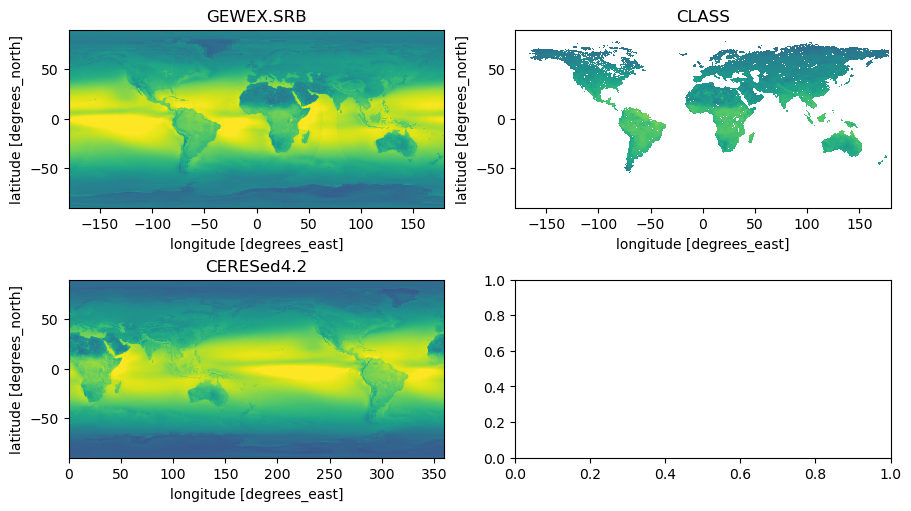

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(9, 5), layout="constrained")
axs = axes.ravel()

i = 0
for v in ["rns"]:
    for p in products[v].keys():
        print(v,p)
        products[v][p][0].mean(dim="time").plot(ax=axs[i], cmap="viridis", vmin=-100, vmax=200, add_labels=True, add_colorbar=False)
        axs[i].set_title(p)

        i += 1

pr GPCCv2018
pr GPCPv2.3
pr CMAPv1904
pr CLASS


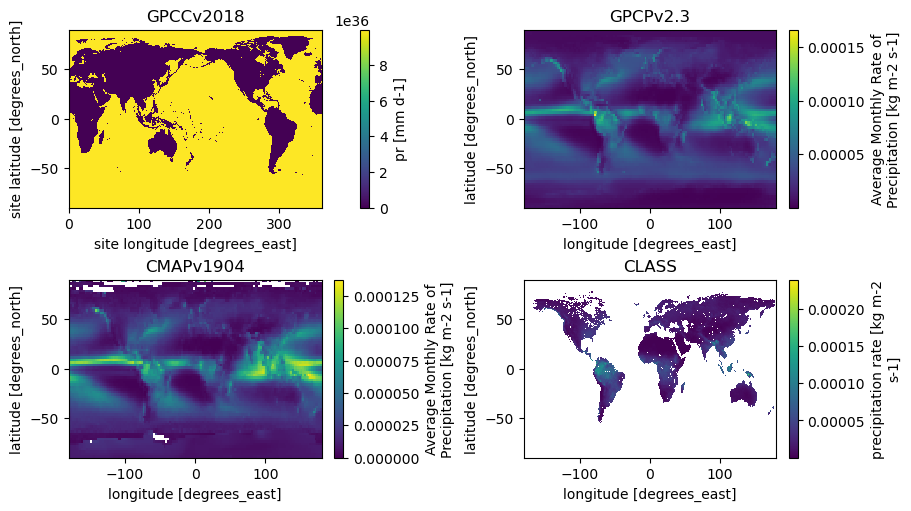

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(9, 5), layout="constrained")
axs = axes.ravel()

i = 0
for v in ["pr"]:
    for p in products[v].keys():
        print(v,p)
        products[v][p][0].mean(dim="time").plot(ax=axs[i], cmap="viridis")#, vmin=-100, vmax=200, add_labels=True, add_colorbar=False)
        axs[i].set_title(p)

        i += 1

In [ ]:
# Seasonal cycle over entire period


#